<a href="https://colab.research.google.com/github/3OMDEH/Machine-Learning-Projects-Beginner-/blob/main/CNN_%7C_Chest_Xray.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Libraries and Data Access**

In [ ]:
#@title Libraries
import numpy as np
import pandas as pd
import os

# Torch Dependencies
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms.v2 as transforms # Used to apply transformations to the dataset
import torchvision.transforms.functional as F

In [ ]:
#@title Constructing the Path
import kagglehub
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# **Data Preparation**

In [ ]:
#@title Accessing the chest_xray folder
file_list = os.listdir(path)
print(file_list)

chest_xray_path = os.path.join(path, 'chest_xray')
print(f"Contents of chest_xray: {os.listdir(chest_xray_path)}")

['chest_xray']
Contents of chest_xray: ['chest_xray', '__MACOSX', 'val', 'test', 'train']


In [ ]:
#@title Transform Function

width = 256
height = 256


transformation = transforms.Compose([
    # Apply RandomResizedCrop first to handle both cropping and initial resizing
    transforms.RandomResizedCrop((width, height), scale=(0.3, 6), ratio=(1,1)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.5), # Operates on 3 channels
    transforms.Grayscale(num_output_channels=1), # Convert to 1 channel (grayscale)
    transforms.ToTensor(), # Converting the images to PyTorch tensors
    # Update Normalize for single channel grayscale images
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Transformation for validation and test sets (no random augmentations)
val_test_transformation = transforms.Compose([
    transforms.Resize((width, height)), # Resize to desired dimensions
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(), # Convert to PyTorch tensors
    transforms.Normalize(mean=[0.5], std=[0.5]) # Normalize with the same values as training
])

"""
It's generally best practice to apply all geometric and color augmentations first,
then convert the image to a PyTorch tensor, and finally normalize it.
"""

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


"\nIt's generally best practice to apply all geometric and color augmentations first,\nthen convert the image to a PyTorch tensor, and finally normalize it.\n"

In [ ]:
#@title Creating ImageFolder & DataLoaders

# Define the paths for train, validation, and test directories
train_dir = os.path.join(chest_xray_path, 'train')
val_dir = os.path.join(chest_xray_path, 'val')
test_dir = os.path.join(chest_xray_path, 'test')

# Create ImageFolder datasets
train_dataset = torchvision.datasets.ImageFolder(root=train_dir, transform=transformation)
val_dataset = torchvision.datasets.ImageFolder(root=val_dir, transform=val_test_transformation)
test_dataset = torchvision.datasets.ImageFolder(root=test_dir, transform=val_test_transformation)

# Define batch sizes
batch_size = 32

# Create DataLoader instances
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

valid_N = len(val_loader.dataset)

# Print the number of samples in each dataset
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

print(f"Classes: {train_dataset.classes}")

Number of training samples: 5216
Number of validation samples: 16
Number of test samples: 624
Classes: ['NORMAL', 'PNEUMONIA']


# **Model Creation**

In [ ]:
n_classes = 2
kernel_size = 3 # Size of the convolutional filter
img_chs = 1 # 1 because the x-ray images are grayscale
flattened_img_size = 75 * 32 * 32 # Corrected based on 256x256 input after 3 MaxPool2d layers

model = nn.Sequential(
    # First convolution
    nn.Conv2d(img_chs, 25, kernel_size, stride=1, padding=1),  # Output 25 channels, spatial size 256x256
    nn.BatchNorm2d(25),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # Downsamples the feature map to 128x128
    # Second convolution
    nn.Conv2d(25, 50, kernel_size, stride=1, padding=1),  # Output 50 channels, spatial size 128x128
    nn.BatchNorm2d(50),
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),  # Output 50 channels, spatial size 64x64
    # Third convolution
    nn.Conv2d(50, 75, kernel_size, stride=1, padding=1),  # Output 75 channels, spatial size 64x64
    nn.BatchNorm2d(75),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # Output 75 channels, spatial size 32x32
    # Flatten to Dense
    nn.Flatten(),
    nn.Linear(flattened_img_size, 512),
    nn.Dropout(.6),
    nn.ReLU(),
    nn.Linear(512, n_classes)
)

# batch normalization scales the values in the hidden layers to improve training.
# The padding helps maintain the spatial dimensions.

In [ ]:
#@title Compile the model
model = torch.compile(model.to(device))
model

OptimizedModule(
  (_orig_mod): Sequential(
    (0): Conv2d(1, 25, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(25, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(25, 50, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(50, 75, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): BatchNorm2d(75, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (13): Flatten(start_dim=1, end_dim=-1)
    (14): Linear(in_features=76800, out_features=512, bias=True)
    (15): Dropo

In [ ]:
#@title Criterion and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

In [ ]:
#@title Batch Accuracy
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

# **Training the Model**

In [ ]:
#@title Training Function

def train():
  total_loss = 0
  total_correct = 0
  total_samples = 0

  model.train()
  for x,y in train_loader:
      x, y = x.to(device), y.to(device) # Move data to the specified device
      output= model(x)
      optimizer.zero_grad()
      batch_loss = criterion(output, y)
      batch_loss.backward()
      optimizer.step()

      total_loss += batch_loss.item() * len(x) # Accumulate weighted loss
      pred = output.argmax(dim=1, keepdim=True)
      total_correct += pred.eq(y.view_as(pred)).sum().item()
      total_samples += len(x)

  avg_loss = total_loss / total_samples
  avg_accuracy = total_correct / total_samples
  print('Train - Loss: {:.4f} Accuracy: {:.4f}'.format(avg_loss, avg_accuracy))

In [ ]:
#@title Validation Function
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def validate():
    model.eval() # Set the model to evaluation mode
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in test_loader: # Using test_loader for final evaluation
            x, y = x.to(device), y.to(device)
            output = model(x)
            preds = torch.argmax(output, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    # Calculate Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    print("Confusion Matrix:")
    print(cm)

    # Display Confusion Matrix visually
    plt.figure(figsize=(4, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    # Generate and print classification report
    report = classification_report(all_labels, all_preds, target_names=test_dataset.classes)
    print("\nClassification Report:")
    print(report)

Epoch: 0


W0711 20:05:10.344000 755 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode


Train - Loss: 2.8202 Accuracy: 0.7906
Confusion Matrix:
[[141  93]
 [  9 381]]


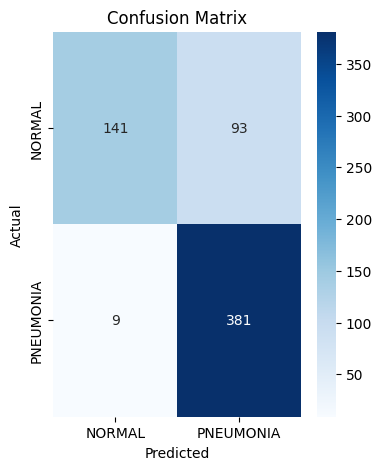


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.94      0.60      0.73       234
   PNEUMONIA       0.80      0.98      0.88       390

    accuracy                           0.84       624
   macro avg       0.87      0.79      0.81       624
weighted avg       0.85      0.84      0.83       624

Epoch: 1
Train - Loss: 0.3550 Accuracy: 0.8497
Confusion Matrix:
[[175  59]
 [ 15 375]]


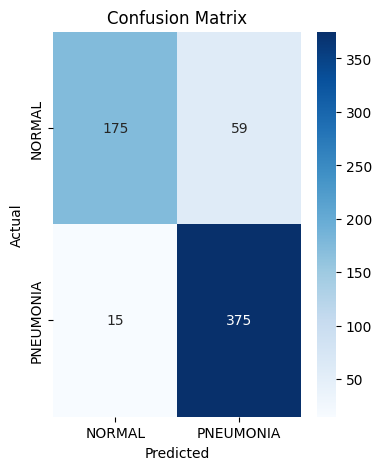


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.92      0.75      0.83       234
   PNEUMONIA       0.86      0.96      0.91       390

    accuracy                           0.88       624
   macro avg       0.89      0.85      0.87       624
weighted avg       0.89      0.88      0.88       624

Epoch: 2
Train - Loss: 0.3379 Accuracy: 0.8612
Confusion Matrix:
[[196  38]
 [ 39 351]]


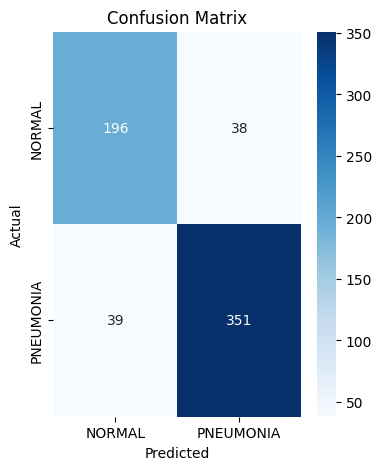


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.83      0.84      0.84       234
   PNEUMONIA       0.90      0.90      0.90       390

    accuracy                           0.88       624
   macro avg       0.87      0.87      0.87       624
weighted avg       0.88      0.88      0.88       624

Epoch: 3
Train - Loss: 0.3494 Accuracy: 0.8503
Confusion Matrix:
[[170  64]
 [ 18 372]]


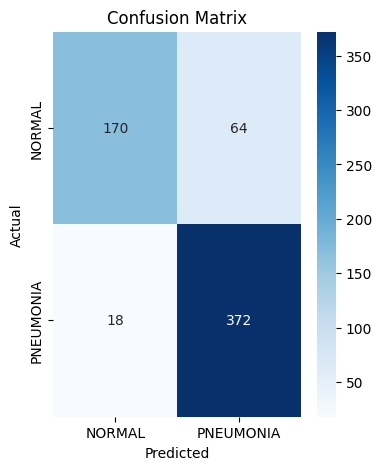


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.90      0.73      0.81       234
   PNEUMONIA       0.85      0.95      0.90       390

    accuracy                           0.87       624
   macro avg       0.88      0.84      0.85       624
weighted avg       0.87      0.87      0.87       624

Epoch: 4
Train - Loss: 0.3421 Accuracy: 0.8602
Confusion Matrix:
[[222  12]
 [133 257]]


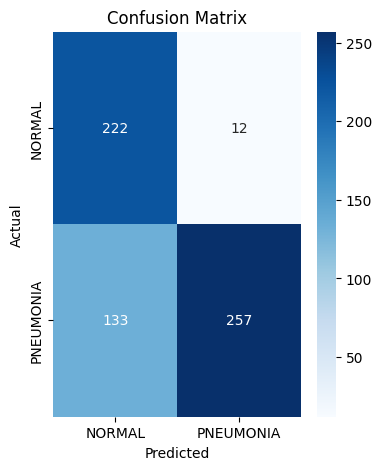


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.63      0.95      0.75       234
   PNEUMONIA       0.96      0.66      0.78       390

    accuracy                           0.77       624
   macro avg       0.79      0.80      0.77       624
weighted avg       0.83      0.77      0.77       624

Epoch: 5
Train - Loss: 0.3265 Accuracy: 0.8696
Confusion Matrix:
[[189  45]
 [ 36 354]]


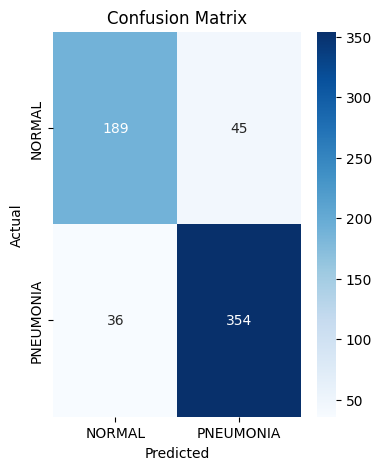


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.84      0.81      0.82       234
   PNEUMONIA       0.89      0.91      0.90       390

    accuracy                           0.87       624
   macro avg       0.86      0.86      0.86       624
weighted avg       0.87      0.87      0.87       624

Epoch: 6
Train - Loss: 0.3379 Accuracy: 0.8719
Confusion Matrix:
[[212  22]
 [ 97 293]]


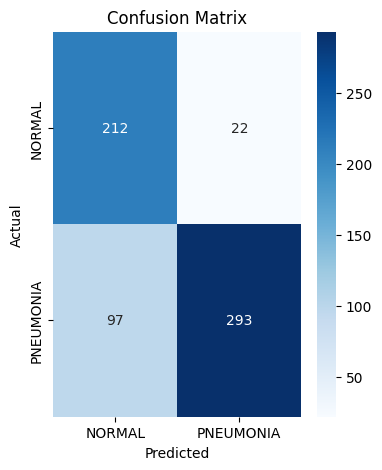


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.69      0.91      0.78       234
   PNEUMONIA       0.93      0.75      0.83       390

    accuracy                           0.81       624
   macro avg       0.81      0.83      0.81       624
weighted avg       0.84      0.81      0.81       624



In [ ]:
epochs = 7

for epoch in range(epochs):
    print('Epoch: {}'.format(epoch))
    train()
    validate()